## COMP5328 - Advanced Machine Learning
## Assignment 1: Non-negative Matrix Factorization
----------------------------------------------------------------------------------------

**(Semester 2, 2025)**

In this ipython notebook, we provide some example code for assignment1.
+ Load Data.
    - ORL dataset. 
    - Extended YaleB dataset. 
    - AR dataset (**optional**).
+ Perform Evaluation. 
   - Relative Reconstruction Errors.
   - Accuracy, NMI (**optional**).

Lecturer: Tongliang Liu.

**Note: All datasets can be used only for this assignment and you are not allowed to distribute these datasets. If you want to use AR dataset, you need to apply it by yourself (we do not provide AR dataset due to the problem of license, please find more details in http://www2.ece.ohio-state.edu/~aleix/ARdatabase.html).**

## 1. Load Dataset

### 1.0 Data Folder

In [1]:
# The structure of data folder.
!ls -l ../data

total 0
drwxrwxrwx 1 root root 512 Sep 29 00:44 CroppedYaleB
drwxrwxrwx 1 root root 512 Sep 29 00:45 ORL


### 1.1 Load ORL Dataset and Extended YaleB Dataset.
+ ORL dataset contains ten different images of each of 40 distinct subjects. For some subjects, the images were taken at different times, varying the lighting, facial expressions (open / closed eyes, smiling / not smiling) and facial details (glasses / no glasses). All the images were taken against a dark homogeneous background with the subjects in an upright, frontal position (with tolerance for some side movement). The size of each image is 92x112 pixels, with 256 grey levels per pixel. To further reduce the computation complexity, you can resize all images to 30x37 pixels.

+ Extended YaleB dataset contains 2414 images of 38 human subjects under 9 poses and 64 illumination conditions. All images are manually aligned, cropped, and then resized to 168x192 pixels. To further reduce the computation complexity, you can resize all images to 42x48 pixels.

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

def load_data(root='../data/CroppedYaleB', reduce=4):
    """ 
    Load ORL (or Extended YaleB) dataset to numpy array.
    
    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):
        
        if not os.path.isdir(os.path.join(root, person)):
            continue
        
        for fname in os.listdir(os.path.join(root, person)):    
            
            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue
            
            if not fname.endswith('.pgm'):
                continue
                
            # load image.
            img = Image.open(os.path.join(root, person, fname))
            img = img.convert('L') # grey image.

            # reduce computation complexity.
            img = img.resize([s//reduce for s in img.size])

            # Preprocessing - Includes histogram equalization and rescaling intensities

            # convert image to numpy array.
            img = np.asarray(img).reshape((-1,1))

            # Histogram equalization - Removes illumination bias (eg. shadows)
            img = cv2.equalizeHist(img)

            # Rescale intensities to [10,245] - outlier bright/dark spots should get treated as noise
            img = img.astype(np.float32)  # convert to float
            img = 245 * (img - img.min()) / (img.max() - img.min()) + 10
            img = img.astype(np.uint8)  # convert back to integer

            # collect data and label.
            images.append(img)
            labels.append(i)

    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels

In [3]:
np.random.seed(42)      # for replicability

# Load ORL dataset.
X_orl, Y_orl = load_data(root='../data/ORL', reduce=3)
print('ORL dataset: X.shape = {}, Y.shape = {}'.format(X_orl.shape, Y_orl.shape))

# Load Extended YaleB dataset.
X_yaleb, Y_yaleb = load_data(root='../data/CroppedYaleB', reduce=4)
print('Extended YalB dataset: X.shape = {}, Y.shape = {}'.format(X_yaleb.shape, Y_yaleb.shape))


ORL dataset: X.shape = (1110, 400), Y.shape = (400,)
Extended YalB dataset: X.shape = (2016, 2414), Y.shape = (2414,)


### 1.2 Load AR Dataset (Optional) 
AR dataset contains 2600 images of 100 individuals (50 male and 50 female). All images have been cropped and resized to 120x165 pixels. To further reduce the computation complexity, you can resize all images to 40x55 pixels.

In [16]:
def load_data_AR(root='data/CroppedAR', reduce=3):
    """ 
    Load AR dataset to numpy array.
    
    Args:
        root: path to AR dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []
    
    for fname in os.listdir(root):
        
        if not fname.endswith('.bmp'):
            continue
        
        # get label.
        label = int(fname[2:5])
        if fname[0] == 'W': # start from 50
            label += 50
        
        # load image.
        img = Image.open(os.path.join(root, fname))
        img = img.convert('L') # grey
        
        # reduce computation complexity.
        img = img.resize([s//reduce for s in img.size])
   
        # TODO: preprocessing.
        
        # convert image to numpy array.
        img = np.asarray(img).reshape((-1,1))
        
        # collect data and label.
        images.append(img)
        labels.append(label)
        
    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)
    
    return images, labels

In [5]:
# X, Y = load_data_AR(root='data/CroppedAR', reduce=3)
# print('AR dataset: X.shape = {}, Y.shape = {}'.format(X.shape, Y.shape))

---------------------------


## Factorization & Encoding Algorithms: 

### Multiplicative Update Factorization

In [4]:
def factorize_multiplicative_update(V, k=200, max_iter=501, verbose=False):
    """
    Multiplicative Update Factorization (Lee & Seung algorithm)
    Args:
        V: Input matrix (m x n)
        k: Number of features (rank)
        max_iter: Number of iterations
        verbose: optional logging
    
    Returns:
        W: Dictionary matrix (m x k)
        H: Activation matrix (k x n)
        loss_function: List of loss values during training
    """
    m, n = V.shape

    # Initialize W and H
    W = np.random.rand(m, k)
    H = np.random.rand(k, n)

    loss_function = []

    if verbose == True: print(f'\nStarting -> Multiplicative Update Factorization')

    for i in range(max_iter):
        # Compute loss
        loss = np.linalg.norm((V - W @ H), 'fro') ** 2    # Frobenius norm
        
        loss_function.append(loss)

        # Update H
        H = H * ((W.T @ V) / (W.T @ W @ H + 1e-10))   # Hadamard product - element wise multiplication
            
        # Update W
        W = W * ((V @ H.T) / (W @ H @ H.T + 1e-10))   # Hadamard product - element wise multiplication

        # Fix scaling ambiguity
        Wnorm = np.linalg.norm(W, axis=0, keepdims=True) + 1e-10
        W = W / Wnorm
        H = H * Wnorm.T

        if verbose == True and i % 100 == 0: print(f"Iteration {i}, Loss: {loss:.2f}")

    return W, H, loss_function
    

### Robust Non-negative Matrix Factorization (L1-Norm)

In [5]:
def factorize_robust_l1(X, E, k=200, max_iter=501, lamda=0.5, verbose=False):
    """
    Robust Non-negative Matrix Factorization (L1-Norm)
    Args:
        X: Input matrix with noise (m x n)
        E: Sparse additive noise
        k: Number of features (rank)
        max_iter: Number of iterations
        lamda: Tradeoff between clean data and sparseness constraint (lower lamda -> model handles noise better)
        verbose: optional logging
    
    Returns:
        U: Dictionary matrix (m x k)
        V: Activation matrix (k x n)
        loss_function: List of loss values during training
    """
    m, n = X.shape

    # Initialize U and V
    U = np.random.rand(m, k)
    V = np.random.rand(k, n)

    # Initialize positive and negative component of E
    Ep = np.maximum(E, 0) 
    En = np.maximum(-E, 0)

    loss_function = []

    if verbose == True: print(f'\nStarting -> Robust Factorization (L1-Norm)')

    for i in range(max_iter):
        # Compute loss (lamda encourages whole columns of E to go to zero rather than just individual entries)
        loss = np.linalg.norm((X - U @ V - E), 'fro') ** 2 + lamda * np.sum(np.linalg.norm(E, ord=1, axis=0) ** 2)

        loss_function.append(loss)

        # Update U
        U = U * ((np.maximum(X - E, 0) @ V.T) / (U @ V @ V.T + 1e-10))   # Hadamard product - element wise multiplication

        # Augmentation trick to update V, Ep and En simultaneously

        # Define V_bar
        V_bar = np.vstack([V, Ep, En])      # (k + 2m) x n

        # Define X_bar
        X_bar = np.vstack([X, np.zeros((1, n))])   # (m + 1) x n

        # Define U_bar
        I = np.eye(m, m)        # Identity matrix, m x m
        U_bar = np.hstack([U, I, -I])
        zero_row = np.zeros((1, k))                   # 1 x k
        ones_row_x_root_lamda = np.ones((1, m)) * np.sqrt(lamda)     # 1 x m
        last_row = np.hstack([zero_row, ones_row_x_root_lamda, ones_row_x_root_lamda])  # 1 x (k + 2m)
        U_bar = np.vstack([U_bar, last_row])        # (m + 1) x (k + 2m)

        # Define S
        S = np.abs(U_bar.T @ U_bar)

        term1 = (U_bar.T @ U_bar @ V_bar) / ((S @ V_bar) + 1e-10)
        term2 = (U_bar.T @ X_bar) / ((S @ V_bar) + 1e-10)

        V_bar = np.maximum(0, V_bar - (V_bar * term1) + (V_bar * term2))        # Hadamard product - element wise multiplication

        # Split V_bar back into parts
        V  = V_bar[:k, :]
        Ep = V_bar[k:k+m, :]
        En = V_bar[k+m:, :]

        # Update E
        E = Ep - En

        # Fix scaling ambiguity
        Unorm = np.linalg.norm(U, axis=0, keepdims=True) + 1e-10
        U = U / Unorm
        V = V * Unorm.T

        if verbose == True and i % 100 == 0: print(f"Iteration {i}, Loss: {loss:.2f}")

    return U, V, E, loss_function
    

### Encoding Multiplicative Update

In [6]:
def encode_multiplicative_update(W, V, max_iter=101, verbose=False):
    """
    Multiplicative NMF encoding using a trained dictionary.
    
    Args:
        W: Learned dictionary matrix (m x k) from training
        V: Input matrix (m x n)
        max_iter: Number of iteration
        verbose: optional logging
        
    Returns:
        Vc: Cleaned input matrix (m x n)
        H: Activation matrix from encoding (k x n)
        loss_function: List of loss values during encoding on test data
    """
    m, n = V.shape
    k = W.shape[1]

    # Initialize H randomly
    H = np.random.rand(k, n)

    loss_function = []

    if verbose == True: print(f'\nStarting -> Multiplicative Update Encoding')
    
    for i in range(max_iter):
        H = H * (W.T @ V) / (W.T @ W @ H + 1e-10)

        # Compute reconstruction error
        Vr = W @ H
        loss = np.linalg.norm(V - Vr, "fro")

        loss_function.append(loss)

        if verbose == True and i % 50 == 0: print(f"Iteration {i}, Loss: {loss:.2f}")

    Vc = W @ H

    return Vc, H, loss_function


### Encoding Robust NMF (L1-Norm)

In [7]:
def encode_robust_nmf_l1(U, X, max_iter=101, lamda=0.5, verbose=False):
    """
    Robust NMF L1 encoding using a trained dictionary.

    Args:
        U: Learned dictionary matrix (m x k) from training
        X: Input matrix (m x n)
        max_iter: Number of iterations
        lamda: Sparsity tradeoff
    
    Returns:
        Xc: Cleaned input matrix (m x n)
        V: Activation matrix from encoding (k x n)
        loss_function: List of loss values during encoding on test data
    """
    m, n = X.shape
    k = U.shape[1]

    # Initialize V randomly
    V = np.random.rand(k, n)

    # Initialize positive and negative component of E
    Ep = np.random.rand(m, n)
    En = np.random.rand(m, n)
    E = Ep - En

    # Build augmented matrices

    # Define V_bar
    V_bar = np.vstack([V, Ep, En])      # (k + 2m) x n

    # Define X_bar
    X_bar = np.vstack([X, np.zeros((1, n))])   # (m + 1) x n

    # Define U_bar
    I = np.eye(m, m)        # Identity matrix, m x m
    U_bar = np.hstack([U, I, -I])
    zero_row = np.zeros((1, k))                   # 1 x k
    ones_row_x_root_lamda = np.ones((1, m)) * np.sqrt(lamda)     # 1 x m
    last_row = np.hstack([zero_row, ones_row_x_root_lamda, ones_row_x_root_lamda])  # 1 x (k + 2m)
    U_bar = np.vstack([U_bar, last_row])        # (m + 1) x (k + 2m)

    # Define S
    S = np.abs(U_bar.T @ U_bar)

    loss_function = []

    if verbose == True: print(f'\nStarting -> Robust Encoding (L1-Norm)')

    for i in range(max_iter):
        # Refine V_bar (since U_bar is already trained no need to recompute)

        term1 = (U_bar.T @ U_bar @ V_bar) / ((S @ V_bar) + 1e-10)
        term2 = (U_bar.T @ X_bar) / ((S @ V_bar) + 1e-10)

        V_bar = np.maximum(0, V_bar - (V_bar * term1) + (V_bar * term2)) 

        # Split V_bar back into parts
        V  = V_bar[:k, :]
        Ep = V_bar[k:k+m, :]
        En = V_bar[k+m:, :]

        E = Ep - En

        # Full reconstruction including estimated noise
        Xr = U @ V + E

        # Compute current loss
        loss = np.linalg.norm(X - Xr, 'fro')**2 + lamda * np.sum(np.linalg.norm(E, ord=1, axis=0)**2)

        loss_function.append(loss)

        if verbose == True and i % 50 == 0: print(f"Iteration {i}, Loss: {loss:.2f}")

    V  = V_bar[:k, :]

    Xc = U @ V

    return Xc, V, loss_function
    

## Helper Functions

In [8]:
from sklearn.decomposition import TruncatedSVD

def add_salt_pepper_noise(X, p=0.4, r=0.3):
    """
    Add salt-and-pepper noise.
    
    Args:
        X: image array of shape (features, samples)
        p: % of pixel values that would be modied
        r: ratio of being 255 (white)
    
    Returns:
        Xn: noisy version of X (features, samples)
    """
    Xn = X.copy()
    m, n = X.shape  # features × samples
    
    # mask specifying pixels that get corrupted
    mask = np.random.rand(m, n) < p
    
    # mask specifying salt vs pepper
    salt_mask = np.random.rand(m, n) < r
    
    # Apply salt (255) and pepper (0)
    Xn[mask & salt_mask] = 255
    Xn[mask & ~salt_mask] = 0
    
    return Xn

def reduce_with_svd(X, n_components=200):
    """
    Reduce dimensionality using TruncatedSVD.
    
    Args:
        X: samples × features (transposed)
        n_components: number of components

    Returns:
        X_reduced: samples x components (transposed)
        svd: fitted TruncatedSVD object
    """
    svd = TruncatedSVD(n_components=n_components, random_state=0)
    X_reduced = svd.fit_transform(X)  # samples x components
    
    return X_reduced, svd, svd.components_

def pad_to_svd_components(X, svd):
    """
    Pads NMF-reduced data with zeros to n_components(svd) x samples.

    Args:
        X: k(Robust NMF) x samples
        svd: fitted TruncatedSVD object

    Returns:
        X_full: n_components(svd) x samples
    """
    k, n_samples = X.shape
    X_full = np.zeros((svd.components_.shape[0], n_samples))
    X_full[:k, :] = X
    return X_full
    

## Tuning using RRE (Run one split)

We used an iterative approach to choose the best hyperparameters for each model and each dataset

For YaleB dataset, Robust NMF (L1-Norm) struggles to keep up with the number of samples. We have therefore focused largely to make the model run efficiently in a reduced svd space (putting less weight on performance). As a result the evaluation results of the Robust NMF model (for YaleB dataset) is expected to be much worse

*Note: For Visualization code to run, you only need to run this section and all helper functions before this.

In [9]:
from sklearn.model_selection import train_test_split

output_dir = "../nmf_results"
os.makedirs(output_dir, exist_ok=True)

i = 1
test_size = 0.1
verbose = True

# Define hyperparameters
max_iter_m = 201 # iterations for Multiplicative Update
max_iter_r = 201 # iterations for Robust NMF L1
max_iter_e = 51 # For encoding, both Multiplicative Update and Robust NMF L1
k_orl_m = 400 # k for orl dataset, for Multiplicative Update processing
k_orl_r = 800 # k for orl dataset, for Robust NMF L1 (in image space)
k_yaleb_m = 800 # k for yaleb dataset, for Multiplicative Update processing
k_yaleb_r = 600 # k for yaleb dataset, for Robust NMF L1 (in svd reduced space) - have to choose low value else computation becomes expensive
lamda_orl = 1e-2 # lamda for orl dataset
lamda_yaleb = 1e-3 # lamda for yaleb dataset
padding_factor = 1.25 # extra dimensionality you keep before applying NMF in SVD reduced space

for dataset in ['orl', 'yaleb'] : # Can set to only one dataset here

    if dataset == 'orl':
        X, Y = X_orl, Y_orl
    elif dataset == 'yaleb':
        X, Y = X_yaleb, Y_yaleb

    print(f'*****Starting -> Evaluation with defined variables for dataset {dataset}')
            
    # Train-test split only accepts samples x features
    X_train, X_test, Y_train, Y_test = train_test_split(X.T, Y, test_size=test_size, random_state=1)
    X_train = X_train.T  # features × samples
    X_test  = X_test.T   # features × samples

    # Add Noise
    X_test_n1 = add_salt_pepper_noise(X_test, p=0.3, r=0.3)
    X_test_n2 = add_salt_pepper_noise(X_test, p=0.3, r=0.7)
    X_test_n3 = add_salt_pepper_noise(X_test, p=0.5, r=0.3)
    X_test_n4 = add_salt_pepper_noise(X_test, p=0.6, r=0.7)

    # Robust NMF L1 processing must be handled differently for orl and yaleb, since orl dataset images are not aligned
    if dataset == 'orl':
        Dm, Am, _ = factorize_multiplicative_update(X_train, k=k_orl_m, max_iter=max_iter_m, verbose=verbose)
        Dr, Ar, _, _ = factorize_robust_l1(X_train, np.zeros_like(X_train), k=k_orl_r, max_iter=max_iter_r, lamda=lamda_orl, verbose=verbose)
    elif dataset == 'yaleb':
        Dm, Am, _ = factorize_multiplicative_update(X_train, k=k_yaleb_m, max_iter=max_iter_m, verbose=verbose)
        X_train_reduced, svd, svd_components = reduce_with_svd(X_train.T, n_components=int(padding_factor*k_yaleb_r))
        Dr, Ar, _, _ = factorize_robust_l1(X_train_reduced.T, np.zeros_like(X_train_reduced.T), k=k_yaleb_r, max_iter=max_iter_r, lamda=lamda_yaleb, verbose=verbose)

    # works for both datset
    print(f'\n*****Starting => Encoding test data for varying noise intensites')
    X_test_c0m, A_test_0m, _ = encode_multiplicative_update(Dm, X_test, max_iter=max_iter_e, verbose=True)
    X_test_c1m, A_test_1m, _ = encode_multiplicative_update(Dm, X_test_n1, max_iter=max_iter_e, verbose=True)
    X_test_c2m, A_test_2m, _ = encode_multiplicative_update(Dm, X_test_n2, max_iter=max_iter_e, verbose=True)
    X_test_c3m, A_test_3m, _ = encode_multiplicative_update(Dm, X_test_n3, max_iter=max_iter_e, verbose=True)
    X_test_c4m, A_test_4m, _ = encode_multiplicative_update(Dm, X_test_n4, max_iter=max_iter_e, verbose=True)

    if dataset == 'orl':
        # Encode in image space
        X_test_c0r, A_test_0r, _ = encode_robust_nmf_l1(Dr, X_test, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
        X_test_c1r, A_test_1r, _ = encode_robust_nmf_l1(Dr, X_test_n1, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
        X_test_c2r, A_test_2r, _ = encode_robust_nmf_l1(Dr, X_test_n2, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
        X_test_c3r, A_test_3r, _ = encode_robust_nmf_l1(Dr, X_test_n3, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
        X_test_c4r, A_test_4r, _ = encode_robust_nmf_l1(Dr, X_test_n4, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)

    elif dataset == 'yaleb':
        # Encode in svd space
        X_test_c0r_reduced, A_test_0r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
        X_test_c0r_full = pad_to_svd_components(X_test_c0r_reduced, svd)  # n_components x n_test
        X_test_c0r = svd.inverse_transform(X_test_c0r_full.T).T           # features x n_test

        X_test_c1r_reduced, A_test_1r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n1.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
        X_test_c1r_full = pad_to_svd_components(X_test_c1r_reduced, svd)  # n_components x n_test
        X_test_c1r = svd.inverse_transform(X_test_c1r_full.T).T           # features x n_test

        X_test_c2r_reduced, A_test_2r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n2.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
        X_test_c2r_full = pad_to_svd_components(X_test_c2r_reduced, svd)  # n_components x n_test
        X_test_c2r = svd.inverse_transform(X_test_c2r_full.T).T           # features x n_test
                
        X_test_c3r_reduced, A_test_3r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n3.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
        X_test_c3r_full = pad_to_svd_components(X_test_c3r_reduced, svd)  # n_components x n_test
        X_test_c3r = svd.inverse_transform(X_test_c3r_full.T).T           # features x n_test

        X_test_c4r_reduced, A_test_4r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n4.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
        X_test_c4r_full = pad_to_svd_components(X_test_c4r_reduced, svd)  # n_components x n_test
        X_test_c4r = svd.inverse_transform(X_test_c4r_full.T).T           # features x n_test

    RRE_m = [
        np.linalg.norm(X_test_c0m - X_test) / np.linalg.norm(X_test_c0m),
        np.linalg.norm(X_test_c1m - X_test) / np.linalg.norm(X_test_c1m),
        np.linalg.norm(X_test_c2m - X_test) / np.linalg.norm(X_test_c2m),
        np.linalg.norm(X_test_c3m - X_test) / np.linalg.norm(X_test_c3m),
        np.linalg.norm(X_test_c4m - X_test) / np.linalg.norm(X_test_c4m)
    ]

    RRE_r = [
        np.linalg.norm(X_test_c0r - X_test) / np.linalg.norm(X_test_c0r),
        np.linalg.norm(X_test_c1r - X_test) / np.linalg.norm(X_test_c1r),
        np.linalg.norm(X_test_c2r - X_test) / np.linalg.norm(X_test_c2r),
        np.linalg.norm(X_test_c3r - X_test) / np.linalg.norm(X_test_c3r),
        np.linalg.norm(X_test_c4r - X_test) / np.linalg.norm(X_test_c4r)
    ]

    print("\nRRE (Multiplicative NMF):", np.round(RRE_m, 4))
    print("RRE (Robust NMF):", np.round(RRE_r, 4))

    np.savez(os.path.join(output_dir, f"split_{dataset}_{i}.npz"),
        X_train=X_train, X_test=X_test, Y_train=Y_train, Y_test=Y_test,
        Dm = Dm, Am = Am, Dr = Dr, Ar = Ar,
        X_test_c0m = X_test_c0m, X_test_c0r = X_test_c0r, A_test_0m = A_test_0m, A_test_0r = A_test_0r,
        X_test_n1 = X_test_n1, X_test_c1m = X_test_c1m, A_test_1m = A_test_1m, X_test_c1r = X_test_c1r, A_test_1r = A_test_1r,
        X_test_n2 = X_test_n2, X_test_c2m = X_test_c2m, A_test_2m = A_test_2m, X_test_c2r = X_test_c2r, A_test_2r = A_test_2r,
        X_test_n3 = X_test_n3, X_test_c3m = X_test_c3m, A_test_3m = A_test_3m, X_test_c3r = X_test_c3r, A_test_3r = A_test_3r,
        X_test_n4 = X_test_n4, X_test_c4m = X_test_c4m, A_test_4m = A_test_4m, X_test_c4r = X_test_c4r, A_test_4r = A_test_4r)

    print(f'\n*****Finished saving file split_{dataset}_{i}.npz\n')


*****Starting -> Evaluation with defined variables for dataset orl

Starting -> Multiplicative Update Factorization


Iteration 0, Loss: 2434453519.09
Iteration 100, Loss: 152001970.36
Iteration 200, Loss: 77849505.05

Starting -> Robust Factorization (L1-Norm)
Iteration 0, Loss: 3811466240.98
Iteration 100, Loss: 115081482.22
Iteration 200, Loss: 44967140.08

*****Starting => Encoding test data for varying noise intensites

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 10841.07
Iteration 50, Loss: 4924.78

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 17928.25
Iteration 50, Loss: 15600.47

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 18192.60
Iteration 50, Loss: 15436.22

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 20744.51
Iteration 50, Loss: 18935.02

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 22876.80
Iteration 50, Loss: 20002.42

Starting -> Robust Encoding (L1-Norm)
Iteration 0, Loss: 133814193.77
Iteration 50, Loss: 17850669.38

Starting -> Robust Encoding (L1-Norm)
Iteration 0, Loss: 320313119.42
Iteration 50

## Train-Test splits, Model Training & Running Experiments

#### *NOTE: No need to run this section if goal is to use existing experiments (executed run results are already in nmf_results folder). This section will take ~2hr to execute

In [ ]:
from sklearn.model_selection import train_test_split
import joblib

output_dir = "../nmf_results"
os.makedirs(output_dir, exist_ok=True)

n_splits = 5
test_size = 0.1
verbose = True

# Using best / optimal hyperparameters
max_iter_m = 201 # iterations for Multiplicative Update
max_iter_r = 201 # iterations for Robust NMF L1
max_iter_e = 51 # For encoding, both Multiplicative Update and Robust NMF L1
k_orl_m = 400 # k for orl dataset, for Multiplicative Update processing
k_orl_r = 800 # k for orl dataset, for Robust NMF L1 (in image space)
k_yaleb_m = 800 # k for yaleb dataset, for Multiplicative Update processing
k_yaleb_r = 600 # k for yaleb dataset, for Robust NMF L1 (in svd reduced space) - have to choose low value else computation becomes expensive
lamda_orl = 1e-2 # lamda for orl dataset
lamda_yaleb = 1e-3 # lamda for yaleb dataset
padding_factor = 1.25 # extra dimensionality you keep before applying NMF in SVD reduced space

for dataset in ['orl', 'yaleb'] :

    if dataset == 'orl':
        X, Y = X_orl, Y_orl
    elif dataset == 'yaleb':
        X, Y = X_yaleb, Y_yaleb

    for i in range(n_splits):

        if verbose == True: print(f'*****Starting -> test-train split {i+1} of {n_splits} for {dataset}')
        
        # Train-test split only accepts samples x features
        X_train, X_test, Y_train, Y_test = train_test_split(X.T, Y, test_size=test_size, random_state=i)
        X_train = X_train.T  # features × samples
        X_test  = X_test.T   # features × samples

        # Add Noise
        X_test_n1 = add_salt_pepper_noise(X_test, p=0.3, r=0.3)
        X_test_n2 = add_salt_pepper_noise(X_test, p=0.3, r=0.7)
        X_test_n3 = add_salt_pepper_noise(X_test, p=0.5, r=0.3)
        X_test_n4 = add_salt_pepper_noise(X_test, p=0.6, r=0.7)

        # Robust NMF L1 processing must be handled differently for orl and yaleb, since orl dataset images are not aligned
        if dataset == 'orl':
            Dm, Am, _ = factorize_multiplicative_update(X_train, k=k_orl_m, max_iter=max_iter_m, verbose=verbose)
            Dr, Ar, _, _ = factorize_robust_l1(X_train, np.zeros_like(X_train), k=k_orl_r, max_iter=max_iter_r, lamda=lamda_orl, verbose=verbose)
        elif dataset == 'yaleb':
            Dm, Am, _ = factorize_multiplicative_update(X_train, k=k_yaleb_m, max_iter=max_iter_m, verbose=verbose)
            X_train_reduced, svd, svd_components = reduce_with_svd(X_train.T, n_components=int(padding_factor*k_yaleb_r))
            Dr, Ar, _, _ = factorize_robust_l1(X_train_reduced.T, np.zeros_like(X_train_reduced.T), k=k_yaleb_r, max_iter=max_iter_r, lamda=lamda_yaleb, verbose=verbose)
        
        # works for both datset
        print(f'\n*****Starting => Encoding test data for varying noise intensites')
        X_test_c0m, A_test_0m, _ = encode_multiplicative_update(Dm, X_test, max_iter=max_iter_e, verbose=True)
        X_test_c1m, A_test_1m, _ = encode_multiplicative_update(Dm, X_test_n1, max_iter=max_iter_e, verbose=True)
        X_test_c2m, A_test_2m, _ = encode_multiplicative_update(Dm, X_test_n2, max_iter=max_iter_e, verbose=True)
        X_test_c3m, A_test_3m, _ = encode_multiplicative_update(Dm, X_test_n3, max_iter=max_iter_e, verbose=True)
        X_test_c4m, A_test_4m, _ = encode_multiplicative_update(Dm, X_test_n4, max_iter=max_iter_e, verbose=True)

        if dataset == 'orl':
            # Encode in image space
            X_test_c0r, A_test_0r, _ = encode_robust_nmf_l1(Dr, X_test, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
            X_test_c1r, A_test_1r, _ = encode_robust_nmf_l1(Dr, X_test_n1, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
            X_test_c2r, A_test_2r, _ = encode_robust_nmf_l1(Dr, X_test_n2, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
            X_test_c3r, A_test_3r, _ = encode_robust_nmf_l1(Dr, X_test_n3, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)
            X_test_c4r, A_test_4r, _ = encode_robust_nmf_l1(Dr, X_test_n4, max_iter=max_iter_e, lamda=lamda_orl, verbose=True)

        elif dataset == 'yaleb':
            # Encode in svd space
            X_test_c0r_reduced, A_test_0r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
            X_test_c0r_full = pad_to_svd_components(X_test_c0r_reduced, svd)  # n_components x n_test
            X_test_c0r = svd.inverse_transform(X_test_c0r_full.T).T           # features x n_test

            X_test_c1r_reduced, A_test_1r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n1.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
            X_test_c1r_full = pad_to_svd_components(X_test_c1r_reduced, svd)  # n_components x n_test
            X_test_c1r = svd.inverse_transform(X_test_c1r_full.T).T           # features x n_test

            X_test_c2r_reduced, A_test_2r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n2.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
            X_test_c2r_full = pad_to_svd_components(X_test_c2r_reduced, svd)  # n_components x n_test
            X_test_c2r = svd.inverse_transform(X_test_c2r_full.T).T           # features x n_test
            
            X_test_c3r_reduced, A_test_3r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n3.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
            X_test_c3r_full = pad_to_svd_components(X_test_c3r_reduced, svd)  # n_components x n_test
            X_test_c3r = svd.inverse_transform(X_test_c3r_full.T).T           # features x n_test

            X_test_c4r_reduced, A_test_4r, _ = encode_robust_nmf_l1(Dr, svd.transform(X_test_n4.T).T, max_iter=max_iter_e, lamda=lamda_yaleb, verbose=True)
            X_test_c4r_full = pad_to_svd_components(X_test_c4r_reduced, svd)  # n_components x n_test
            X_test_c4r = svd.inverse_transform(X_test_c4r_full.T).T           # features x n_test

        np.savez(os.path.join(output_dir, f"split_{dataset}_{i+1}.npz"),
            X_train=X_train, X_test=X_test, Y_train=Y_train, Y_test=Y_test,
            Dm = Dm, Am = Am, Dr = Dr, Ar = Ar,
            X_test_c0m = X_test_c0m, X_test_c0r = X_test_c0r, A_test_0m = A_test_0m, A_test_0r = A_test_0r,
            X_test_n1 = X_test_n1, X_test_c1m = X_test_c1m, A_test_1m = A_test_1m, X_test_c1r = X_test_c1r, A_test_1r = A_test_1r,
            X_test_n2 = X_test_n2, X_test_c2m = X_test_c2m, A_test_2m = A_test_2m, X_test_c2r = X_test_c2r, A_test_2r = A_test_2r,
            X_test_n3 = X_test_n3, X_test_c3m = X_test_c3m, A_test_3m = A_test_3m, X_test_c3r = X_test_c3r, A_test_3r = A_test_3r,
            X_test_n4 = X_test_n4, X_test_c4m = X_test_c4m, A_test_4m = A_test_4m, X_test_c4r = X_test_c4r, A_test_4r = A_test_4r)

        if verbose == True: print(f'\n*****Finished saving files for -> split {i+1}\n')
        

*****Starting -> test-train split 1 of 5 for orl

Starting -> Multiplicative Update Factorization
Iteration 0, Loss: 2437622457.64
Iteration 100, Loss: 151720834.23
Iteration 200, Loss: 77811232.80

Starting -> Robust Factorization (L1-Norm)
Iteration 0, Loss: 3807827556.39
Iteration 100, Loss: 116086711.95
Iteration 200, Loss: 45098727.54

*****Starting => Encoding test data for varying noise intensites

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 10468.08
Iteration 50, Loss: 4566.02

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 17735.20
Iteration 50, Loss: 15456.48

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 17893.31
Iteration 50, Loss: 15254.90

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 20676.56
Iteration 50, Loss: 18879.67

Starting -> Multiplicative Update Encoding
Iteration 0, Loss: 22772.02
Iteration 50, Loss: 20001.55

Starting -> Robust Encoding (L1-Norm)
Iteration 0, Loss: 126124343.32
Iteration 50, Los

## Visualization

*Note: Can run standalone if all helper functions are in memory. Code will work properly if you run just one split

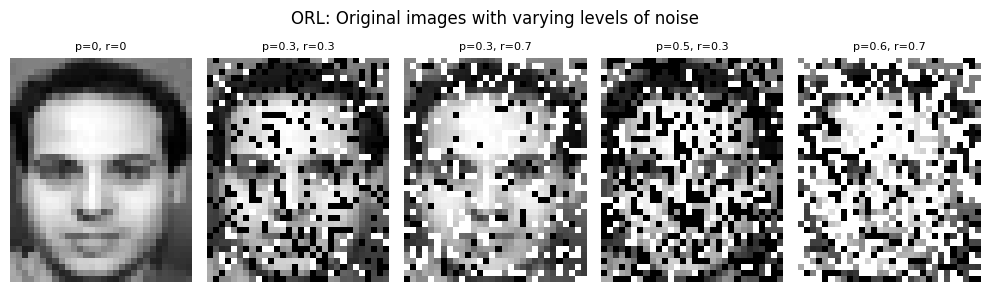

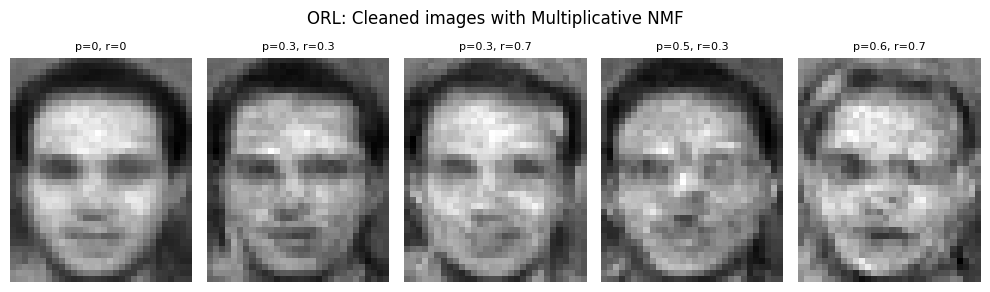

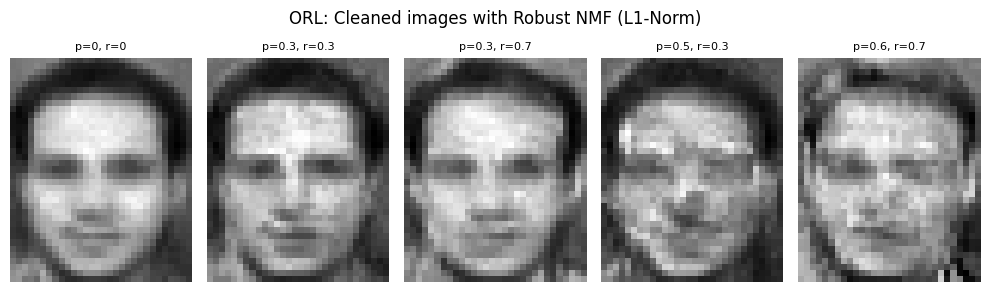

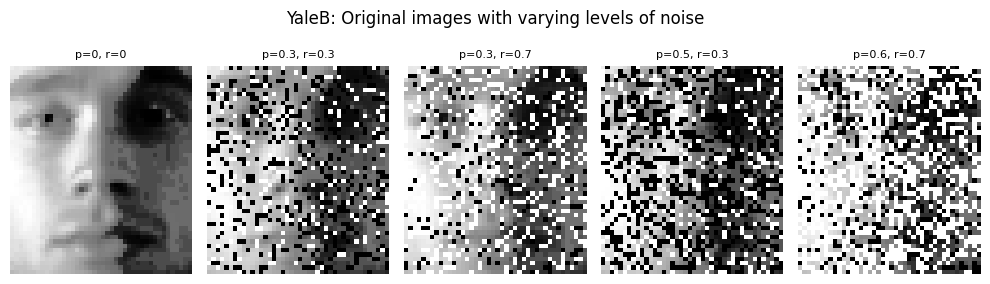

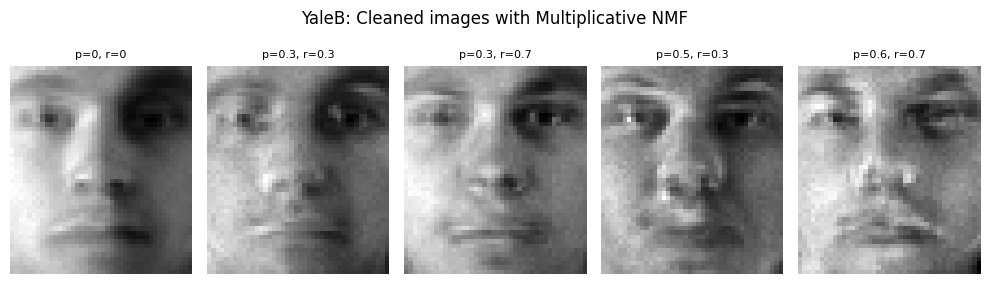

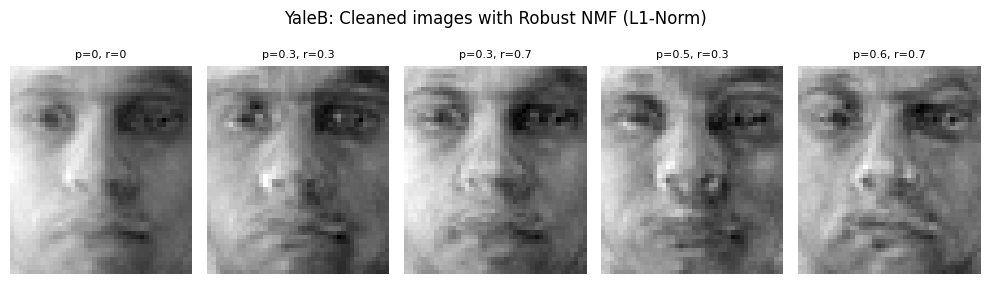

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD

def show_image_grid(filename_key, image_keys, id=0, transform=False, title=None):
    """
    Display images onto a single-row grid.
    """
    filename = "../nmf_results/" + filename_key + ".npz"
    data = np.load(filename, allow_pickle=True)

    noise_hyper_parameters = [(0, 0), (0.3, 0.3), (0.3, 0.7), (0.5, 0.3), (0.6, 0.7)]

    # Deduce dataset from filename_key
    dataset = filename_key[6:-2]

    if dataset == "orl":
        height, width = 37, 30
    elif dataset == "yaleb":
        height, width = 48, 42
    else:
        raise ValueError("Unknown dataset")

    # Deduce number of columns
    n_cols = len(image_keys)

    fig, axes = plt.subplots(1, n_cols, figsize=(2 * n_cols, 3))
    
    for i, (p, r) in zip(range(n_cols), noise_hyper_parameters):

        img = data[image_keys[i]][:, id]

        axes[i].imshow(img.reshape((height, width)), cmap="gray")
        axes[i].set_title(f"p={p}, r={r}", fontsize=8)
        axes[i].axis("off")
    
    fig.suptitle(title)

    plt.tight_layout()
    plt.show()

id=0
image_keys=["X_test", "X_test_n1", "X_test_n2", "X_test_n3", "X_test_n4"]
show_image_grid("split_orl_1", image_keys, id=id, title="ORL: Original images with varying levels of noise")
image_keys = ["X_test_c0m", "X_test_c1m", "X_test_c2m", "X_test_c3m", "X_test_c4m"]
show_image_grid("split_orl_1", image_keys, id=id, title="ORL: Cleaned images with Multiplicative NMF")
image_keys = ["X_test_c0r", "X_test_c1r", "X_test_c2r", "X_test_c3r", "X_test_c4r"]
show_image_grid("split_orl_1", image_keys, id=id, title="ORL: Cleaned images with Robust NMF (L1-Norm)")

id=0
image_keys=["X_test", "X_test_n1", "X_test_n2", "X_test_n3", "X_test_n4"]
show_image_grid("split_yaleb_1", image_keys, id=id, title="YaleB: Original images with varying levels of noise")
image_keys = ["X_test_c0m", "X_test_c1m", "X_test_c2m", "X_test_c3m", "X_test_c4m"]
show_image_grid("split_yaleb_1", image_keys, id=id, title="YaleB: Cleaned images with Multiplicative NMF")
image_keys = ["X_test_c0r", "X_test_c1r", "X_test_c2r", "X_test_c3r", "X_test_c4r"]
show_image_grid("split_yaleb_1", image_keys, id=id, transform=False, title="YaleB: Cleaned images with Robust NMF (L1-Norm)")


## 2. Evaluation Metrics


### 2.1 Relative Reconstruction Errors (RRE)

To compare the robustness of different NMF algorithms, you can use the ```relative reconstruction errors```. Let $V$ denote the contaminated dataset (by adding noise), and $\hat{V}$
 denote the clean dataset. Let $W$ and $H$ denote the factorization results on $V$, the ``relative reconstruction errors`` then can be defined as follows:

\begin{equation}
    RRE = \frac{ \| \hat{V} - WH \|_F }{ \| \hat{V} \|_F}.
\end{equation}

### 2.2 Evaluate Clustering Performance

1. Accuracy.
    
    $$ Acc(Y, Y_{pred}) = \frac{1}{n}\sum\limits_{i=1}^n 1\{Y_{pred}(i) == Y(i)\}$$
        
2. Normalized Mutual Information (NMI).

    $$ NMI(Y, Y_{pred}) = \frac{2 * I(Y, Y_{pred})}{H(Y) + H(Y_{pred})} $$
    
   where $ I(\cdot,\cdot) $ is mutual information and $ H(\cdot) $ is entropy.


For performing comparative analysis between Multiplicative Update NMF and Robust NMF (L1-Norm), we have used 2 Noise Profiles => p, r = (0, 0) and (0.6, 0.7)

*Note: This code will work only when nmf_results folder has data from all splits


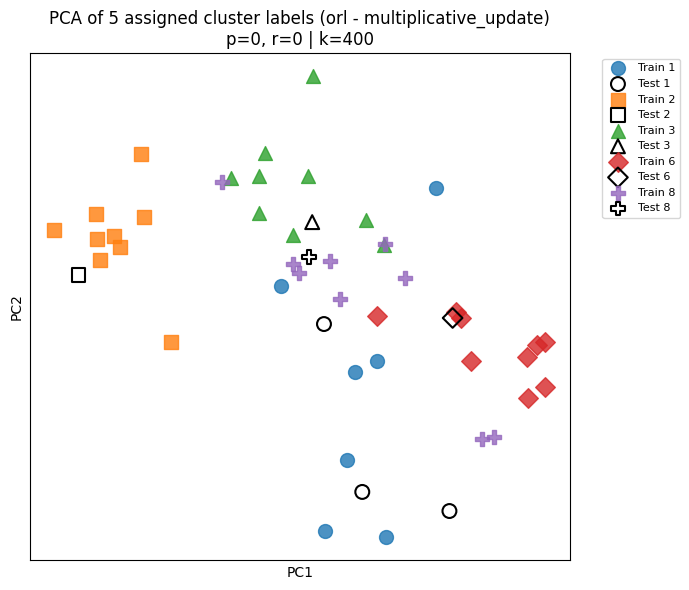

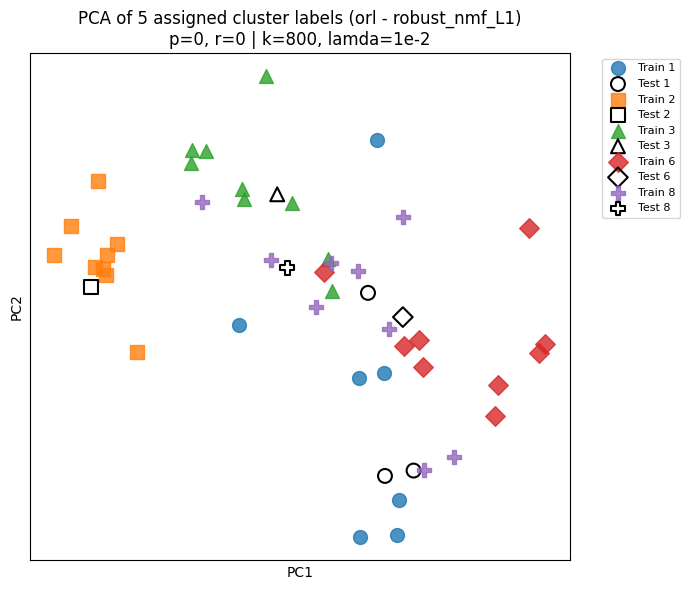

Mean and standard deviations of accuracy parameters over 5 splits


,dataset,method,noise_profile,hyperparameters,RRE_mean,RRE_std,acc_mean,acc_std,nmi_mean,nmi_std
0,orl,multiplicative_update,"p=0, r=0",k=400,0.152,0.004,0.830,0.041,0.942,0.016
1,orl,multiplicative_update,"p=0.3, r=0.3",k=400,0.254,0.002,0.795,0.041,0.916,0.017
2,orl,multiplicative_update,"p=0.3, r=0.7",k=400,0.251,0.003,0.775,0.059,0.912,0.031
3,orl,multiplicative_update,"p=0.5, r=0.3",k=400,0.346,0.003,0.735,0.022,0.891,0.017
4,orl,multiplicative_update,"p=0.6, r=0.7",k=400,0.379,0.003,0.710,0.022,0.870,0.029
5,orl,robust_nmf_L1,"p=0, r=0","k=800, lamda=1e-2",0.147,0.004,0.820,0.054,0.927,0.030
6,orl,robust_nmf_L1,"p=0.3, r=0.3","k=800, lamda=1e-2",0.219,0.003,0.805,0.033,0.918,0.021
7,orl,robust_nmf_L1,"p=0.3, r=0.7","k=800, lamda=1e-2",0.220,0.002,0.815,0.045,0.928,0.024
8,orl,robust_nmf_L1,"p=0.5, r=0.3","k=800, lamda=1e-2",0.327,0.005,0.715,0.014,0.858,0.016
9,orl,robust_nmf_L1,"p=0.6, r=0.7","k=800, lamda=1e-2",0.374,0.004,0.700,0.018,0.862,0.018


In [13]:
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, normalized_mutual_info_score
from collections import Counter
import warnings
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics")

base_dir = "../nmf_results"
datasets = ["orl", "yaleb"]
splits = range(1, 6)

hyperparameters_m = {"orl": "k=400", "yaleb": "k=800"}
hyperparameters_r = {"orl": "k=800, lamda=1e-2", "yaleb": "k=600 (n_components=750), lamda=1e-3"}

method_map = {
    "multiplicative_update": {
        "noise_profile": ["p=0, r=0", "p=0.3, r=0.3", "p=0.3, r=0.7", "p=0.5, r=0.3", "p=0.6, r=0.7"],
        "V_hat": "X_test",
        "V": ["X_test_c0m", "X_test_c1m", "X_test_c2m", "X_test_c3m", "X_test_c4m"],
        "H": ["A_test_0m", "A_test_1m", "A_test_2m", "A_test_3m", "A_test_4m"],
        "W": "Dm",
        "Y": "Y_test",
        "Htrain": "Am",
        "Ytrain": "Y_train"
    },
    "robust_nmf_L1": {
        "noise_profile": ["p=0, r=0", "p=0.3, r=0.3", "p=0.3, r=0.7", "p=0.5, r=0.3", "p=0.6, r=0.7"],
        "V_hat": "X_test",
        "V": ["X_test_c0r", "X_test_c1r", "X_test_c2r", "X_test_c3r", "X_test_c4r"],
        "H": ["A_test_0r", "A_test_1r", "A_test_2r", "A_test_3r", "A_test_4r"],
        "W": "Dr",
        "Y": "Y_test",
        "Htrain": "Ar",
        "Ytrain": "Y_train"
    }
}

def compute_rre(V_hat, V):
    RRE = np.linalg.norm(V_hat - V) / np.linalg.norm(V_hat)
    return RRE

def assign_cluster_label(X, Y):
    kmeans = KMeans(n_clusters=len(set(Y))).fit(X)
    Y_pred = np.zeros(Y.shape)
    for i in set(kmeans.labels_):
        ind = kmeans.labels_ == i
        Y_pred[ind] = Counter(Y[ind]).most_common(1)[0][0] # assign label.
    return Y_pred

def plot_clusters(X_train, y_pred_train, X_test, y_pred_test, title="PCA Scatter plot", max_labels=5):
    # Convert to numpy
    X_train, X_test = np.asarray(X_train), np.asarray(X_test)

    # Fit PCA on combined data so both sets share same projection space
    X_combined = np.vstack([X_train, X_test])
    pca = PCA(n_components=2, random_state=42)
    X_2d_combined = pca.fit_transform(X_combined)

    n_train = len(X_train)
    X_train_2d = X_2d_combined[:n_train]
    X_test_2d = X_2d_combined[n_train:]

    # Build DataFrames
    df_train = pd.DataFrame(X_train_2d, columns=["PC1", "PC2"])
    df_train["label"] = y_pred_train
    df_train["type"] = "train"

    df_test = pd.DataFrame(X_test_2d, columns=["PC1", "PC2"])
    df_test["label"] = y_pred_test
    df_test["type"] = "test"

    df = pd.concat([df_train, df_test])

    # Keep labels that exist in X_test
    test_labels = sorted(df_test["label"].unique())
    selected_labels = test_labels[:max_labels]
    df = df[df["label"].isin(selected_labels)]

    # Define color palette and glyphs
    unique_labels = sorted(selected_labels)
    palette = sns.color_palette("tab10", len(unique_labels))
    color_map = {label: palette[i % len(palette)] for i, label in enumerate(unique_labels)}
    markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'v', '<', '>']
    marker_map = {label: markers[i % len(markers)] for i, label in enumerate(unique_labels)}

    plt.figure(figsize=(7, 6))

    # Plot each label separately
    for label in selected_labels:
        df_label_train = df[(df["label"] == label) & (df["type"] == "train")]
        df_label_test = df[(df["label"] == label) & (df["type"] == "test")]
        color = color_map[label]
        marker = marker_map[label]

        # Plot train samples — filled
        plt.scatter(
            df_label_train["PC1"], df_label_train["PC2"],
            s=100, color=color, marker=marker, alpha=0.8, label=f"Train {label}"
        )

        # Plot test samples — hollow
        plt.scatter(
            df_label_test["PC1"], df_label_test["PC2"],
            s=100, facecolors='none', edgecolors='black', marker=marker,
            linewidths=1.5, label=f"Test {label}"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

results = []

# Perform evaluation
for dataset in datasets:
    for split in splits:
        npz_path = os.path.join(base_dir, f"split_{dataset}_{split}.npz")
        data = np.load(npz_path, allow_pickle=True)

        for method, keys in method_map.items():
            V_hat = data[keys["V_hat"]]
            W = data[keys["W"]]
            Y = data[keys["Y"]]
            Ytrain = data[keys["Ytrain"]]
            Htrain = data[keys["Htrain"]]

            if method == "multiplicative_update":
                hyperparameter = hyperparameters_m
            elif method == "robust_nmf_L1":
                hyperparameter = hyperparameters_r

            for i, (noiseprofile_key, V_key, H_key) in enumerate(zip(keys["noise_profile"], keys["V"], keys["H"])):
                V = data[V_key]
                H = data[H_key]

                rre = compute_rre(V_hat, V)
                Y_pred = assign_cluster_label(H.T, Y)
                acc = accuracy_score(Y, Y_pred)
                nmi = normalized_mutual_info_score(Y, Y_pred)

                # Plot predicted clusters, only plotting ORL as the number of datapoints for YaleB are too many
                if split == 1 and noiseprofile_key == "p=0, r=0" and dataset == "orl":
                    plot_clusters(Htrain.T, Ytrain, H.T, Y.T, title=f"PCA of 5 assigned cluster labels ({dataset} - {method})\n{noiseprofile_key} | {hyperparameter[dataset]}", max_labels=5)

                results.append({
                    "dataset": dataset,
                    "split": split,
                    "method": method,
                    "noise_profile": noiseprofile_key,
                    "hyperparameters": hyperparameter[dataset],
                    "RRE": rre,
                    "acc": acc,
                    "nmi": nmi
                })

# Create DataFrame
df = pd.DataFrame(results)
df = df.round(3)

# Save evaluation results
out_csv = os.path.join(base_dir, "evaluation_results.csv")
df.to_csv(out_csv, index=False)

# Display summary of results
summary = (
    df.groupby(["dataset", "method", "noise_profile", "hyperparameters"])
      .agg(
          RRE_mean=("RRE", "mean"),
          RRE_std=("RRE", "std"),
          acc_mean=("acc", "mean"),
          acc_std=("acc", "std"),
          nmi_mean=("nmi", "mean"),
          nmi_std=("nmi", "std")
      )
      .reset_index()
      .round(3)
)

print("Mean and standard deviations of accuracy parameters over 5 splits")
display(summary)
